In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_csv('facebook_ads_data.csv')

In [7]:
df.head(5)

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [8]:
df['ad_date'] = pd.to_datetime(df['ad_date'])

In [10]:
df_2021 = df[df['ad_date'].dt.year == 2021]

In [12]:
daily_data_2021 = df_2021.groupby('ad_date').agg({
    'total_spend': 'sum',
    'romi': 'mean' 
}).reset_index()

In [16]:
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

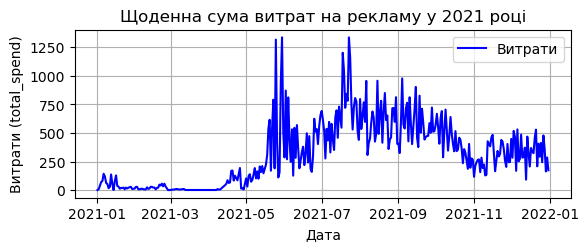

In [18]:
plt.subplot(2, 1, 1) # 2 рядки, 1 колонка, позиція 1
plt.plot(daily_data_2021['ad_date'], daily_data_2021['total_spend'], color='blue', label='Витрати')
plt.title('Щоденна сума витрат на рекламу у 2021 році')
plt.xlabel('Дата')
plt.ylabel('Витрати (total_spend)')
plt.grid(True)
plt.legend()

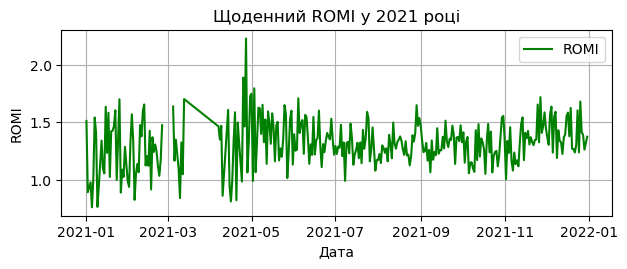

In [17]:
plt.subplot(2, 1, 2) 
plt.plot(daily_data_2021['ad_date'], daily_data_2021['romi'], color='green', label='ROMI')
plt.title('Щоденний ROMI у 2021 році')
plt.xlabel('Дата')
plt.ylabel('ROMI')
plt.grid(True)
plt.legend()

plt.tight_layout() 
plt.show()

In [20]:
campaign_stats = df.groupby('campaign_name').agg({
    'total_spend': 'sum',
    'romi': 'sum'
}).reset_index()

In [21]:
plt.figure(figsize=(12, 12))

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

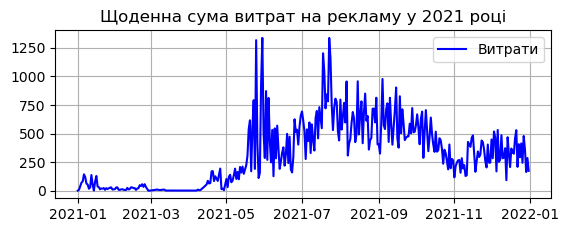

In [22]:
plt.subplot(2, 1, 1) 
plt.plot(daily_data_2021['ad_date'], daily_data_2021['total_spend'], color='blue', label='Витрати')
plt.title('Щоденна сума витрат на рекламу у 2021 році')
plt.grid(True)
plt.legend()

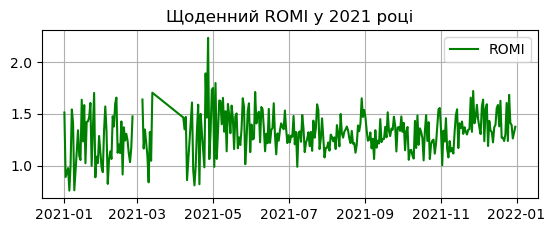

In [23]:
plt.subplot(2, 1, 2)
plt.plot(daily_data_2021['ad_date'], daily_data_2021['romi'], color='green', label='ROMI')
plt.title('Щоденний ROMI у 2021 році')
plt.grid(True)
plt.legend()

In [25]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

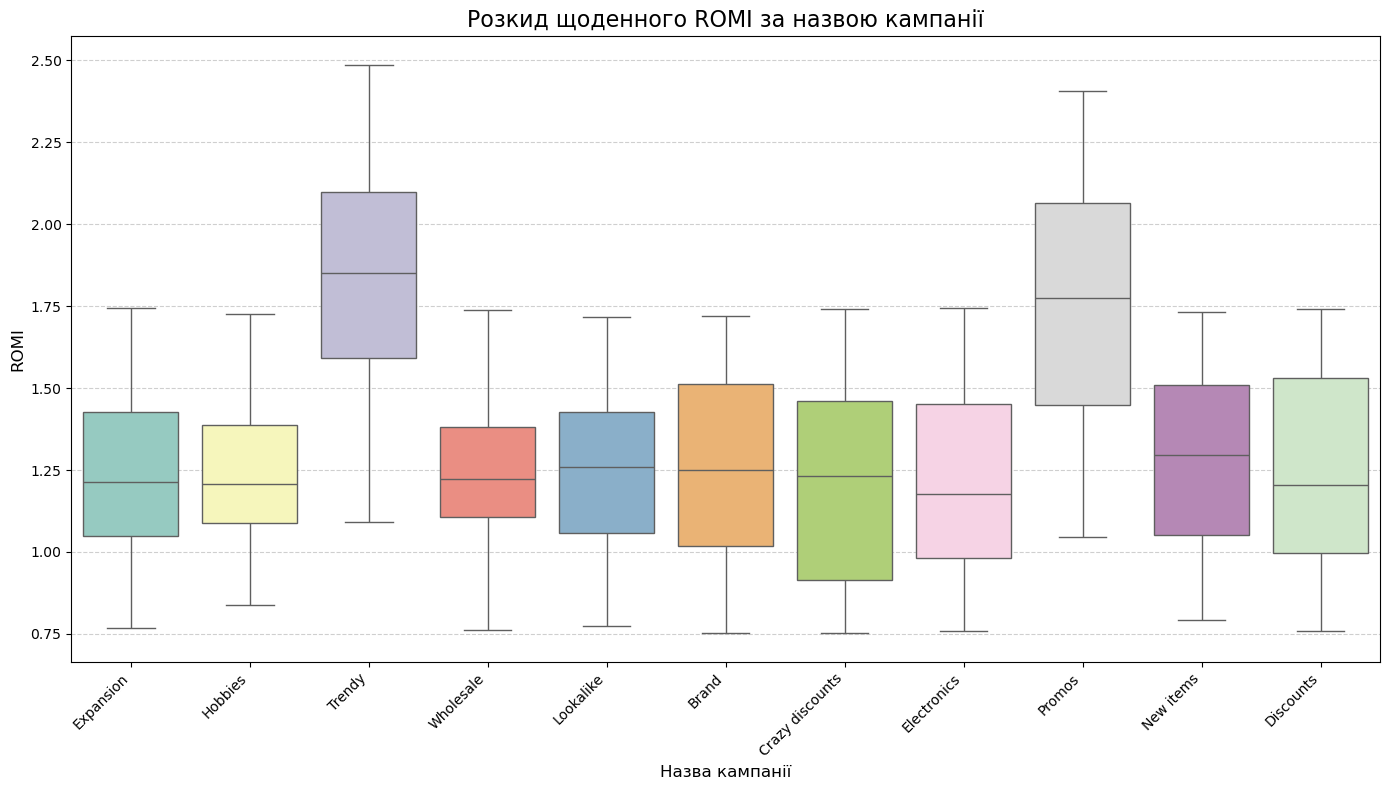

In [32]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df, x='campaign_name', y='romi', hue='campaign_name', palette='Set3', legend=False)

plt.xticks(rotation=45, ha='right')
plt.title('Розкид щоденного ROMI за назвою кампанії', fontsize=16)
plt.xlabel('Назва кампанії', fontsize=12)
plt.ylabel('ROMI', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


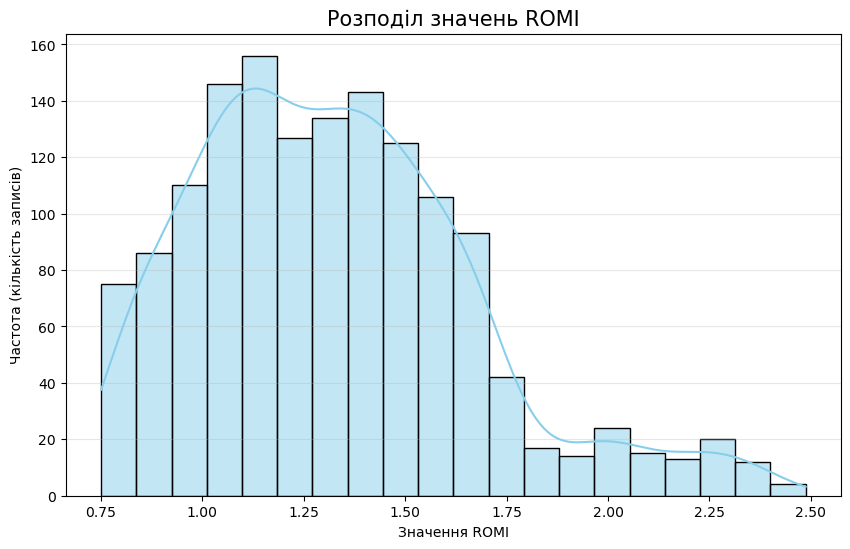

In [33]:

plt.figure(figsize=(10, 6))


sns.histplot(df['romi'], bins=20, kde=True, color='skyblue')

plt.title('Розподіл значень ROMI', fontsize=15)
plt.xlabel('Значення ROMI')
plt.ylabel('Частота (кількість записів)')
plt.grid(axis='y', alpha=0.3)

plt.show()


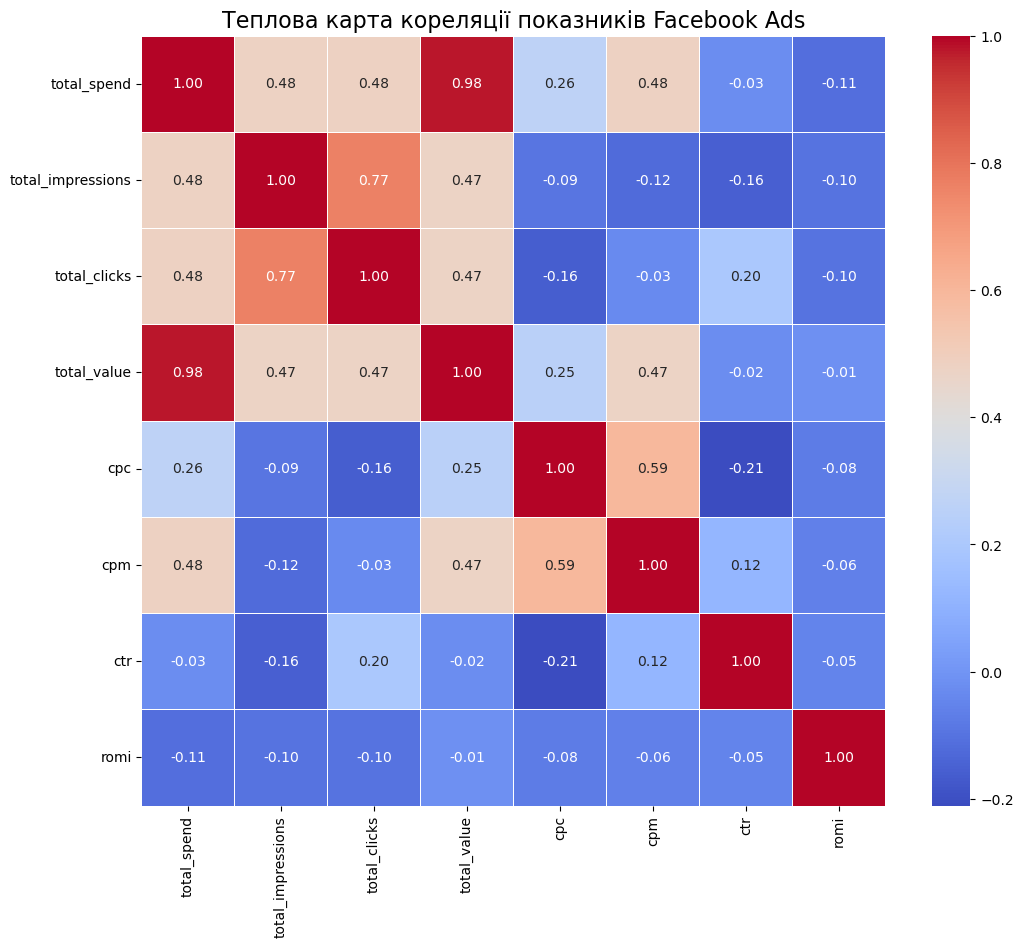

In [36]:
import numpy as np      


numeric_df = df.select_dtypes(include=[np.number])


corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Теплова карта кореляції показників Facebook Ads', fontsize=16)

plt.show()
